# ForgeSight — Predictive Maintenance & Machine Health Intelligence

### Industrial Machine Failure Prediction using Machine Learning

ForgeSight is a predictive maintenance intelligence system designed to estimate machine failure risk from operating conditions and transform machine-learning predictions into actionable machine-health insights.

The project uses the **UCI AI4I 2020 Predictive Maintenance Dataset**, a synthetic dataset designed to model industrial machine behavior.

### Project Objectives

- Analyze industrial machine operating conditions
- Identify patterns associated with machine failure
- Engineer predictive features from machine measurements
- Compare multiple machine-learning models
- Evaluate models using metrics suitable for imbalanced classification
- Validate model stability using stratified 5-fold cross-validation
- Select and train a final production model
- Generate failure probability and a project-defined health index
- Handle invalid and unsupported user inputs safely
- Export the trained model for integration with the ForgeSight application

### Machine Learning Pipeline

**Raw Data → Data Quality → EDA → Feature Engineering → Preprocessing → Model Comparison → Cross-Validation → Final Model → Explainable Prediction → Robustness Testing**

> **Dataset Note:** The AI4I 2020 Predictive Maintenance Dataset is synthetic. ForgeSight does not represent the dataset as live industrial telemetry.

In [1]:
# ============================================================
# FORGESIGHT — ENVIRONMENT & IMPORTS
# ============================================================

import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## 1. Dataset & Problem Definition

Predictive maintenance aims to identify machines that may experience failure before the failure occurs, allowing maintenance teams to intervene proactively.

ForgeSight uses the **AI4I 2020 Predictive Maintenance Dataset**, which contains 10,000 machine observations and operating-condition variables including:

- Machine type
- Air temperature
- Process temperature
- Rotational speed
- Torque
- Tool wear

### Prediction Target

The target variable is:

`Machine failure`

where:

- `0` = No Failure
- `1` = Failure

Because machine failures represent a minority of observations, model evaluation should not rely on accuracy alone. Precision, recall, F1-score, ROC-AUC, and PR-AUC are also considered.

In [2]:
# ============================================================
# LOAD DATASET
# ============================================================

DATA_PATH = "../data/ai4i2020.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("FORGESIGHT — DATASET LOADED")
print("=" * 70)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

display(df.head())

FORGESIGHT — DATASET LOADED
Rows    : 10000
Columns : 14


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Initial Data Inspection

The first inspection establishes the structure, data types, numerical ranges, and general characteristics of the dataset before any transformation is performed.

In [3]:
# ============================================================
# INITIAL DATA INSPECTION
# ============================================================

print("=" * 70)
print("DATASET SHAPE")
print("=" * 70)

print(df.shape)

print("\n" + "=" * 70)
print("COLUMN INFORMATION")
print("=" * 70)

df.info()

print("\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

display(df.describe())

print("\n" + "=" * 70)
print("FIRST FIVE RECORDS")
print("=" * 70)

display(df.head())

DATASET SHAPE
(10000, 14)

COLUMN INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  i

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000



FIRST FIVE RECORDS


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Data Quality Assessment

Before model development, the dataset is checked for:

- Missing values
- Duplicate observations
- Data types
- Unique categorical values
- Target distribution

This ensures that the modeling pipeline is built on a verified dataset.

In [4]:
# ============================================================
# DATA QUALITY CHECK
# ============================================================

missing_values = df.isnull().sum()
duplicate_count = df.duplicated().sum()

print("=" * 70)
print("MISSING VALUES")
print("=" * 70)

display(missing_values)

print("\nTotal missing values:", missing_values.sum())

print("\n" + "=" * 70)
print("DUPLICATE ROWS")
print("=" * 70)

print(duplicate_count)

print("\n" + "=" * 70)
print("MACHINE TYPES")
print("=" * 70)

print(df["Type"].value_counts())

print("\nData quality inspection completed.")

MISSING VALUES


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


Total missing values: 0

DUPLICATE ROWS
0

MACHINE TYPES
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Data quality inspection completed.


## 4. Exploratory Data Analysis

Exploratory data analysis is used to understand the distribution of machine failures and investigate relationships between operating conditions and observed failures.

The analysis focuses on:

- Overall failure distribution
- Failure by machine type
- Tool wear
- Torque
- Rotational speed
- Air temperature
- Process temperature
- Correlation among numerical variables

MACHINE FAILURE DISTRIBUTION
Machine failure
0    9661
1     339
Name: count, dtype: int64

Percentage distribution:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


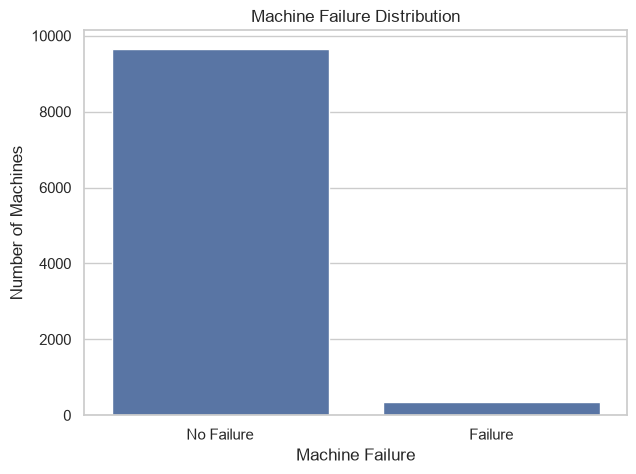

In [5]:
# ============================================================
# TARGET DISTRIBUTION
# ============================================================

failure_counts = df["Machine failure"].value_counts()
failure_percentages = (
    df["Machine failure"]
    .value_counts(normalize=True) * 100
)

print("=" * 70)
print("MACHINE FAILURE DISTRIBUTION")
print("=" * 70)

print(failure_counts)

print("\nPercentage distribution:")
print(failure_percentages.round(2))

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Machine failure"
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Machines")

plt.xticks(
    [0, 1],
    ["No Failure", "Failure"]
)

plt.show()

Failure percentage by machine type:


Machine failure,0,1
Type,,
H,97.91,2.09
L,96.08,3.92
M,97.23,2.77


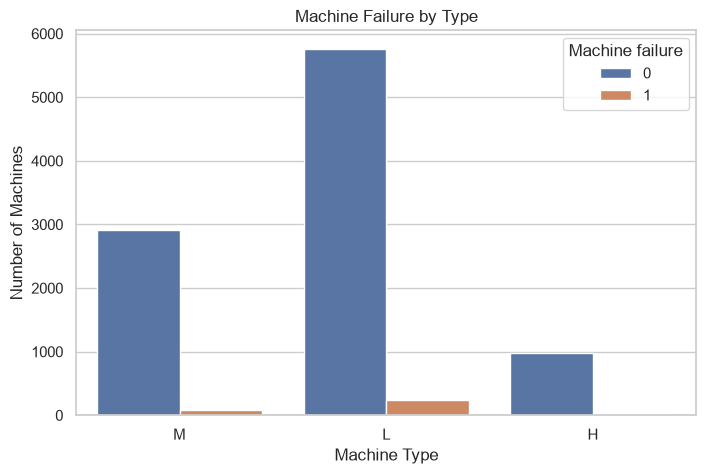

In [6]:
# ============================================================
# FAILURE BY MACHINE TYPE
# ============================================================

failure_by_type = pd.crosstab(
    df["Type"],
    df["Machine failure"],
    normalize="index"
) * 100

print("Failure percentage by machine type:")
display(failure_by_type.round(2))

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Type",
    hue="Machine failure"
)

plt.title("Machine Failure by Type")
plt.xlabel("Machine Type")
plt.ylabel("Number of Machines")

plt.show()

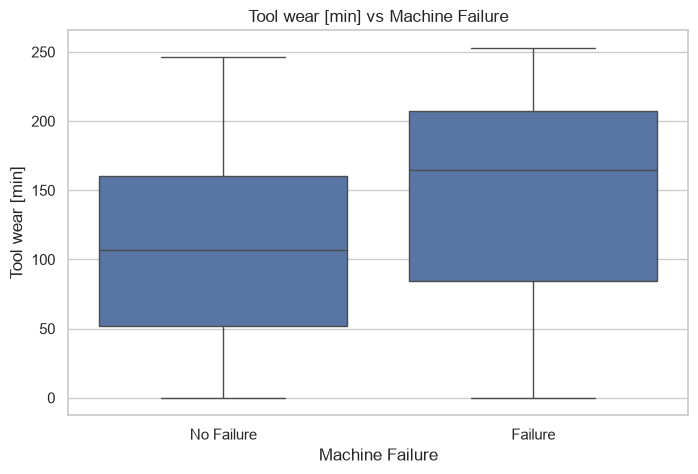

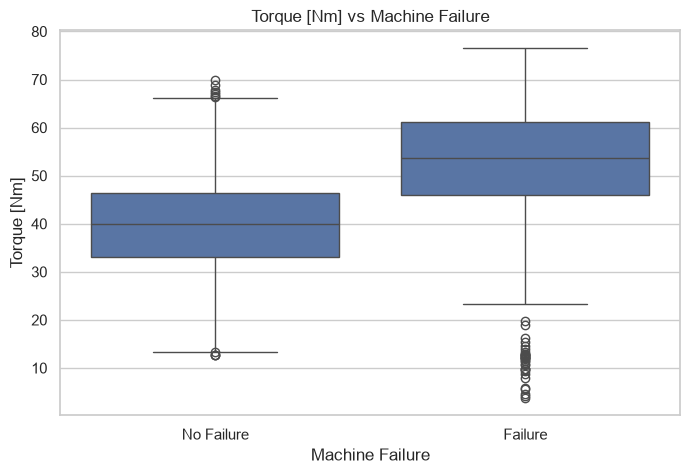

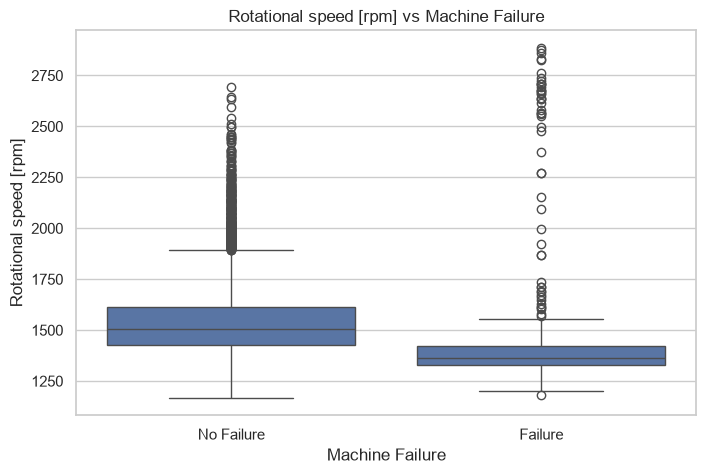

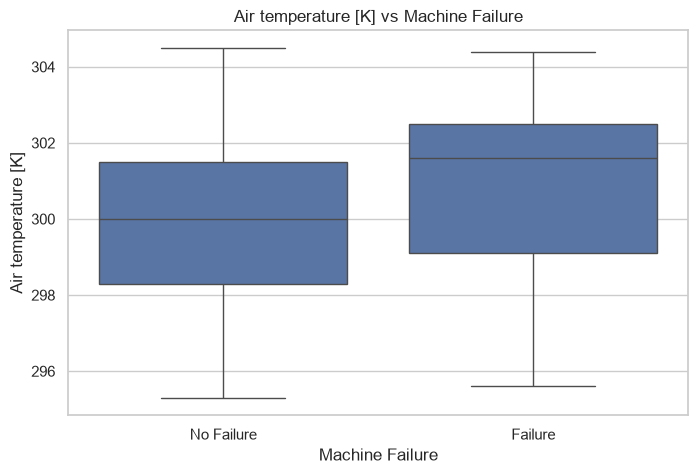

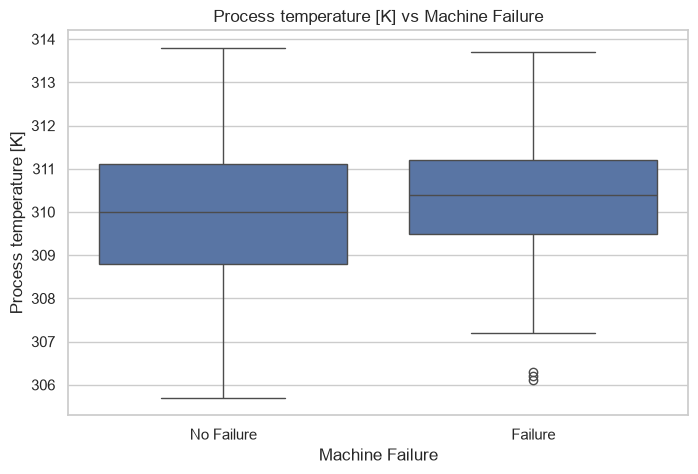

In [7]:
# ============================================================
# OPERATING CONDITION ANALYSIS
# ============================================================

analysis_features = [
    "Tool wear [min]",
    "Torque [Nm]",
    "Rotational speed [rpm]",
    "Air temperature [K]",
    "Process temperature [K]"
]

for feature in analysis_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Machine failure",
        y=feature
    )

    plt.title(
        f"{feature} vs Machine Failure"
    )

    plt.xlabel("Machine Failure")
    plt.ylabel(feature)

    plt.xticks(
        [0, 1],
        ["No Failure", "Failure"]
    )

    plt.show()

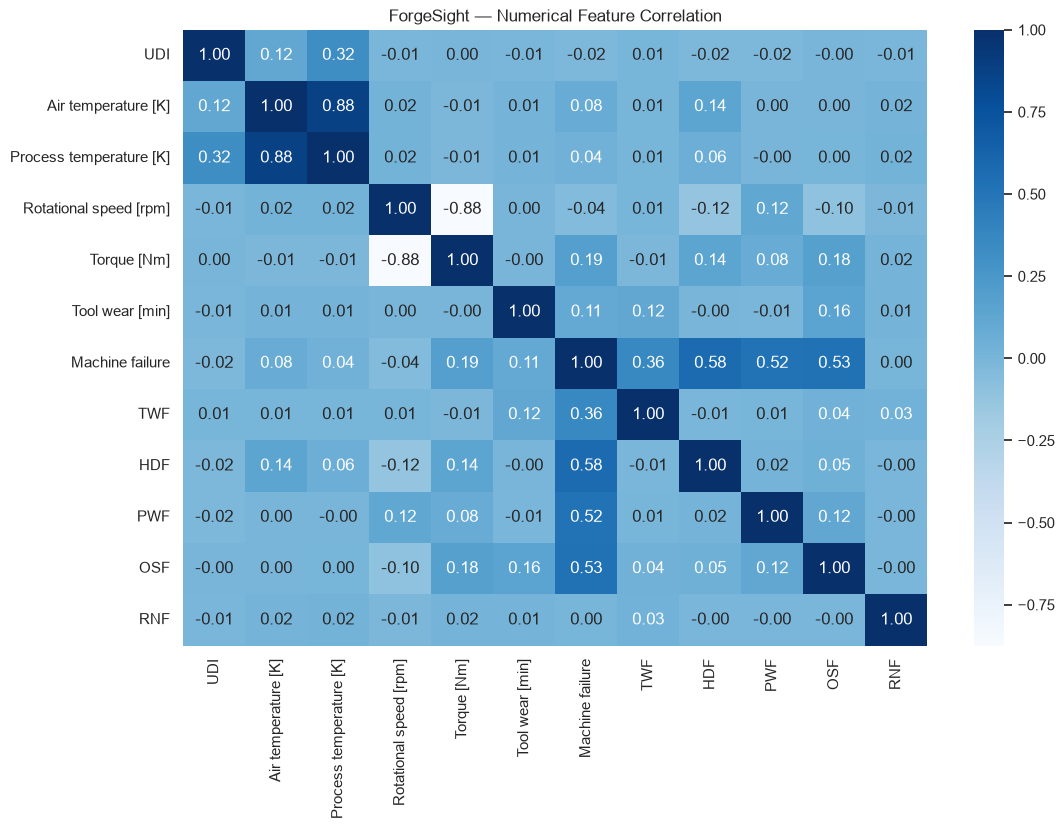

In [8]:
# ============================================================
# NUMERICAL CORRELATION ANALYSIS
# ============================================================

numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title(
    "ForgeSight — Numerical Feature Correlation"
)

plt.show()

## 5. Feature Engineering

Two derived variables are introduced to capture additional operating-condition information.

### Temperature Difference

`Process Temperature − Air Temperature`

This represents the thermal gap between the machine process and surrounding air.

### Power Proxy

`Torque × Rotational Speed`

This is used as a simplified operating-load proxy.

> These engineered features are project-specific predictive variables. The Power Proxy should not be interpreted as a direct measurement of physical electrical or mechanical power.

In [9]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

df["Temperature Difference [K]"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

df["Power Proxy"] = (
    df["Torque [Nm]"]
    * df["Rotational speed [rpm]"]
)

print("Engineered features created successfully.")

display(
    df[
        [
            "Temperature Difference [K]",
            "Power Proxy"
        ]
    ].head()
)

Engineered features created successfully.


,Temperature Difference [K],Power Proxy
0,10.5,66382.8
1,10.5,65190.4
2,10.4,74001.2
3,10.4,56603.5
4,10.5,56320.0


## 6. Feature Selection & Preprocessing

Identifier fields such as `UDI` and `Product ID` are excluded because they identify records rather than represent meaningful machine operating conditions.

The selected predictive variables are:

- Machine type
- Air temperature
- Process temperature
- Rotational speed
- Torque
- Tool wear
- Temperature difference
- Power proxy

Categorical machine types are one-hot encoded.

Numerical variables are standardized.

The preprocessing operations are placed inside the machine-learning pipeline so that transformations are learned only from the relevant training data during evaluation.

In [10]:
# ============================================================
# FEATURE SELECTION
# ============================================================

features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference [K]",
    "Power Proxy"
]

target = "Machine failure"

X = df[features].copy()
y = df[target].copy()

print("=" * 70)
print("SELECTED FEATURES")
print("=" * 70)

for feature in features:
    print("-", feature)

print("\nTarget:", target)

SELECTED FEATURES
- Type
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]
- Temperature Difference [K]
- Power Proxy

Target: Machine failure


In [11]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

categorical_features = [
    "Type"
]

numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference [K]",
    "Power Proxy"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

print("Preprocessing pipeline configured successfully.")

Preprocessing pipeline configured successfully.


## 7. Model Development

Three classification algorithms are evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The dataset is split using a stratified 80/20 train-test split to preserve the failure distribution.

Class weighting is enabled to reduce the effect of the imbalanced target distribution.

In [12]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print(
    "\nTraining failure rate:",
    round(y_train.mean() * 100, 2),
    "%"
)

print(
    "Testing failure rate :",
    round(y_test.mean() * 100, 2),
    "%"
)

TRAIN / TEST SPLIT
Training samples: 8000
Testing samples : 2000

Training failure rate: 3.39 %
Testing failure rate : 3.4 %


In [13]:
# ============================================================
# MODEL DEFINITIONS
# ============================================================

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)


decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=6,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)


random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

print("Models configured successfully.")

for name in models:
    print("-", name)

Models configured successfully.
- Logistic Regression
- Decision Tree
- Random Forest


## 8. Model Evaluation

Models are evaluated on the held-out test set using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

Because failures are relatively rare, **F1-score, recall, ROC-AUC, and PR-AUC** provide more useful information than accuracy alone.

F1-score is used as the primary initial selection criterion.

In [14]:
# ============================================================
# TRAIN & EVALUATE BASELINE MODELS
# ============================================================

results = []
predictions = {}

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    prob = model.predict_proba(
        X_test
    )[:, 1]

    predictions[name] = {
        "pred": pred,
        "prob": prob
    }

    results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_test,
                pred
            ),

        "Precision":
            precision_score(
                y_test,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                pred,
                zero_division=0
            ),

        "F1 Score":
            f1_score(
                y_test,
                pred,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y_test,
                prob
            ),

        "PR-AUC":
            average_precision_score(
                y_test,
                prob
            )
    })


results_df = pd.DataFrame(results)

print("=" * 90)
print("FORGESIGHT — TEST SET MODEL COMPARISON")
print("=" * 90)

display(
    results_df.round(4)
)

FORGESIGHT — TEST SET MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.8585,0.1772,0.8676,0.2943,0.9340,0.4659
1,Decision Tree,0.9590,0.4470,0.8676,0.5900,0.8992,0.8081
2,Random Forest,0.9785,0.6404,0.8382,0.7261,0.9759,0.8378


## 9. Initial Model Selection

The initial model ranking is based primarily on F1-score because the project focuses on detecting machine failures while balancing false positives and false negatives.

The selected candidate is then subjected to stratified 5-fold cross-validation before final production training.

In [15]:
# ============================================================
# INITIAL MODEL SELECTION
# ============================================================

best_test_index = results_df[
    "F1 Score"
].idxmax()

best_test_model_name = results_df.loc[
    best_test_index,
    "Model"
]

best_test_model = models[
    best_test_model_name
]

print(
    "Best model on held-out test set:",
    best_test_model_name
)

print(
    "F1 Score:",
    round(
        results_df.loc[
            best_test_index,
            "F1 Score"
        ],
        4
    )
)

Best model on held-out test set: Random Forest
F1 Score: 0.7261


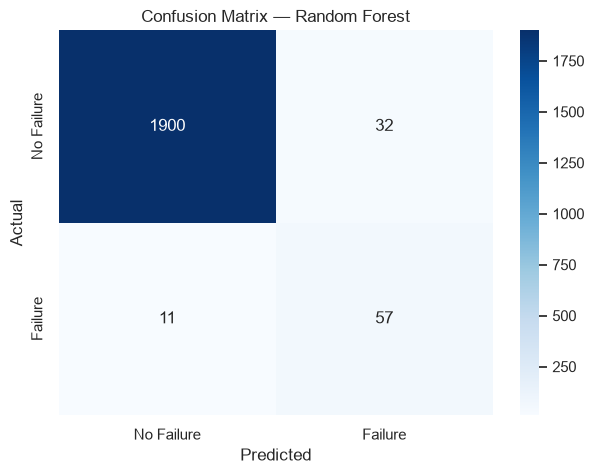

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      1932
     Failure       0.64      0.84      0.73        68

    accuracy                           0.98      2000
   macro avg       0.82      0.91      0.86      2000
weighted avg       0.98      0.98      0.98      2000



In [16]:
# ============================================================
# CONFUSION MATRIX & CLASSIFICATION REPORT
# ============================================================

best_test_pred = predictions[
    best_test_model_name
]["pred"]

cm = confusion_matrix(
    y_test,
    best_test_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Failure",
        "Failure"
    ],
    yticklabels=[
        "No Failure",
        "Failure"
    ]
)

plt.title(
    f"Confusion Matrix — {best_test_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        best_test_pred,
        target_names=[
            "No Failure",
            "Failure"
        ],
        zero_division=0
    )
)

## 10. Stratified 5-Fold Cross-Validation

A stratified 5-fold cross-validation procedure is used to assess whether model performance is reasonably stable across different train-validation splits.

The following metrics are evaluated:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

The mean and standard deviation of F1-score and recall are also retained to assess performance stability.

In [17]:
# ============================================================
# STRATIFIED 5-FOLD CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({

        "Model": name,

        "Accuracy Mean":
            scores[
                "test_accuracy"
            ].mean(),

        "Precision Mean":
            scores[
                "test_precision"
            ].mean(),

        "Recall Mean":
            scores[
                "test_recall"
            ].mean(),

        "F1 Mean":
            scores[
                "test_f1"
            ].mean(),

        "ROC-AUC Mean":
            scores[
                "test_roc_auc"
            ].mean(),

        "PR-AUC Mean":
            scores[
                "test_pr_auc"
            ].mean(),

        "F1 Std":
            scores[
                "test_f1"
            ].std(),

        "Recall Std":
            scores[
                "test_recall"
            ].std()
    })


cv_results_df = pd.DataFrame(
    cv_results
)

print("=" * 100)
print("FORGESIGHT — 5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 100)

display(
    cv_results_df.round(4)
)

FORGESIGHT — 5-FOLD STRATIFIED CROSS-VALIDATION


,Model,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,PR-AUC Mean,F1 Std,Recall Std
0,Logistic Regression,0.8542,0.1674,0.8289,0.2785,0.9239,0.4791,0.0097,0.0274
1,Decision Tree,0.9482,0.3801,0.8350,0.5220,0.8761,0.7427,0.0128,0.0464
2,Random Forest,0.9803,0.6780,0.8112,0.7369,0.9807,0.8602,0.0224,0.0389


## 11. Final Model Selection

Cross-validation provides stronger evidence of model reliability than a single train-test split.

For this dataset and the evaluated baseline models, **Random Forest** provides the strongest overall F1-score in the cross-validation results while maintaining strong recall and PR-AUC performance.

Therefore, Random Forest is selected as the ForgeSight production model.

> Model selection is based on the observed evaluation results rather than assuming a specific algorithm is universally best.

In [18]:
# ============================================================
# FINAL MODEL SELECTION
# ============================================================

cv_best_index = cv_results_df[
    "F1 Mean"
].idxmax()

final_model_name = cv_results_df.loc[
    cv_best_index,
    "Model"
]

print("=" * 70)
print("FINAL MODEL SELECTION")
print("=" * 70)

print(
    "Selected model:",
    final_model_name
)

print(
    "Cross-validation F1:",
    round(
        cv_results_df.loc[
            cv_best_index,
            "F1 Mean"
        ],
        4
    )
)

print(
    "Cross-validation Recall:",
    round(
        cv_results_df.loc[
            cv_best_index,
            "Recall Mean"
        ],
        4
    )
)

print(
    "Cross-validation ROC-AUC:",
    round(
        cv_results_df.loc[
            cv_best_index,
            "ROC-AUC Mean"
        ],
        4
    )
)

print(
    "Cross-validation PR-AUC:",
    round(
        cv_results_df.loc[
            cv_best_index,
            "PR-AUC Mean"
        ],
        4
    )
)

FINAL MODEL SELECTION
Selected model: Random Forest
Cross-validation F1: 0.7369
Cross-validation Recall: 0.8112
Cross-validation ROC-AUC: 0.9807
Cross-validation PR-AUC: 0.8602


## 12. Final Production Model

The selected Random Forest model is now retrained using the complete dataset.

This final model is the artifact that will be consumed by the ForgeSight application.

### Configuration

- Algorithm: Random Forest Classifier
- Number of estimators: 300
- Maximum depth: 10
- Class weighting: Balanced
- Random state: 42
- Parallel processing: Enabled

The preprocessing pipeline remains attached to the model so the application can provide raw machine measurements directly to the prediction pipeline.

In [19]:
# ============================================================
# FINAL PRODUCTION MODEL
# ============================================================

final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

final_model.fit(
    X,
    y
)

print("=" * 70)
print("FINAL FORGESIGHT MODEL")
print("=" * 70)

print("Model:", final_model_name)
print("Training rows:", len(X))
print("Status: Successfully trained")

FINAL FORGESIGHT MODEL
Model: Random Forest
Training rows: 10000
Status: Successfully trained


## 13. Model Explainability

Random Forest feature importance is used to identify the variables that contribute most strongly to the model's predictive decisions.

These values represent **predictive importance rather than causal relationships**.

The feature importance information will later support ForgeSight's risk-driver interface.

TOP PREDICTIVE FACTORS


,Feature,Importance
7,numeric__Tool wear [min],0.217704
5,numeric__Rotational speed [rpm],0.217014
6,numeric__Torque [Nm],0.208901
9,numeric__Power Proxy,0.189443
8,numeric__Temperature Difference [K],0.089603
3,numeric__Air temperature [K],0.042694
4,numeric__Process temperature [K],0.024002
1,categorical__Type_L,0.004764
2,categorical__Type_M,0.004280
0,categorical__Type_H,0.001595


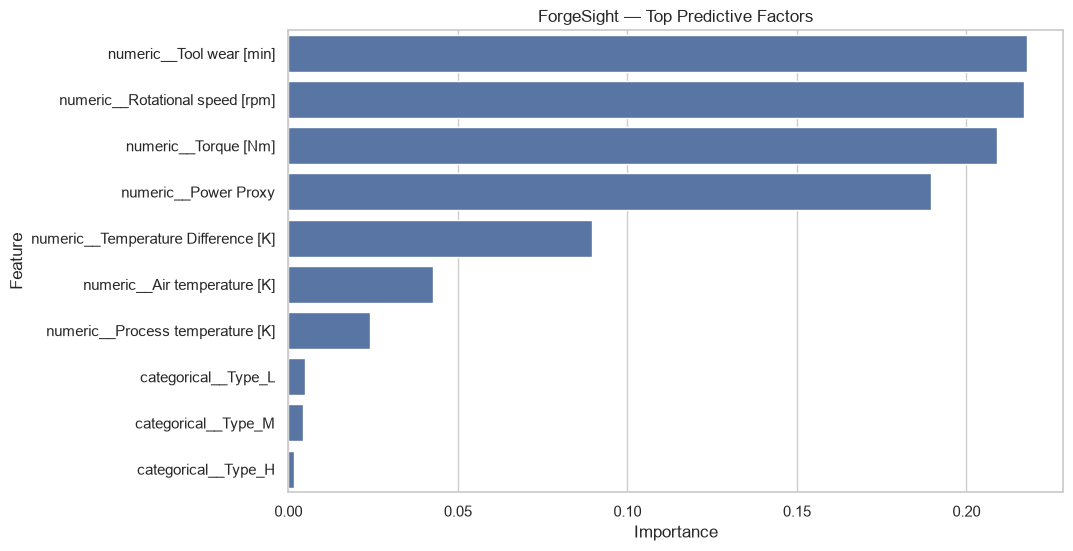

In [20]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

rf_preprocessor = (
    final_model
    .named_steps["preprocessor"]
)

rf_classifier = (
    final_model
    .named_steps["model"]
)

feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

importances = (
    rf_classifier
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

print("=" * 70)
print("TOP PREDICTIVE FACTORS")
print("=" * 70)

display(
    feature_importance_df.head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "ForgeSight — Top Predictive Factors"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 14. ForgeSight Health Index

ForgeSight converts model-estimated failure probability into a product-level health indicator.

### Formula

`Health Index = (1 − Failure Probability) × 100`

### Risk Categories

| Health Index | Risk Level |
|---:|---|
| 80–100 | Healthy |
| 60–79 | Monitor |
| 40–59 | At Risk |
| 0–39 | Critical |

> **Important:** The ForgeSight Health Index is a project-defined risk indicator derived from model-estimated failure probability. It is not an industry-standard machine-health metric.

## 15. Production Prediction Engine

The prediction engine follows a controlled processing pipeline:

**Input → Validation → Feature Engineering → Preprocessing → Model Prediction → Failure Probability → Health Index → Risk Level → Recommendation**

Input validation is intentionally performed before model inference.

The engine handles:

- Missing values
- Invalid machine types
- Non-numeric values
- Non-finite values
- Negative or unsupported operating values
- Invalid temperature relationships
- Invalid model outputs
- Unexpected prediction errors

In [21]:
# ============================================================
# FORGESIGHT — PRODUCTION PREDICTION ENGINE
# ============================================================

def calculate_health_index(
    failure_probability
):
    """
    Calculate the project-defined ForgeSight Health Index.

    Parameters
    ----------
    failure_probability : float
        Model-estimated probability of machine failure.

    Returns
    -------
    float
        Health Index from 0 to 100.
    """

    probability = float(
        failure_probability
    )

    probability = np.clip(
        probability,
        0.0,
        1.0
    )

    health = (
        1.0 - probability
    ) * 100

    return round(
        float(
            np.clip(
                health,
                0.0,
                100.0
            )
        ),
        2
    )


def determine_risk_level(
    health_index
):
    """
    Convert Health Index into a ForgeSight risk category.
    """

    if health_index >= 80:
        return "Healthy"

    elif health_index >= 60:
        return "Monitor"

    elif health_index >= 40:
        return "At Risk"

    return "Critical"


def generate_recommendation(
    risk_level
):
    """
    Generate a maintenance recommendation
    based on the project-defined risk level.
    """

    recommendations = {

        "Healthy":
            "Continue normal operation under "
            "routine maintenance procedures.",

        "Monitor":
            "Continue operation with increased "
            "monitoring and planned inspection.",

        "At Risk":
            "Schedule a maintenance inspection and "
            "review tool condition and operating load.",

        "Critical":
            "Prioritize maintenance inspection before "
            "continued operation."
    }

    return recommendations[
        risk_level
    ]


def validate_machine_input(
    machine_type,
    air_temperature,
    process_temperature,
    rotational_speed,
    torque,
    tool_wear
):
    """
    Validate machine operating conditions
    before model inference.
    """

    errors = []

    # Machine type validation
    if machine_type not in [
        "L",
        "M",
        "H"
    ]:
        errors.append(
            "Machine type must be L, M, or H."
        )

    raw_values = {

        "Air temperature":
            air_temperature,

        "Process temperature":
            process_temperature,

        "Rotational speed":
            rotational_speed,

        "Torque":
            torque,

        "Tool wear":
            tool_wear
    }

    values = {}

    # Numeric validation
    for name, value in raw_values.items():

        if value is None:

            errors.append(
                f"{name} is required."
            )

            continue

        if (
            isinstance(value, str)
            and not value.strip()
        ):

            errors.append(
                f"{name} is required."
            )

            continue

        try:

            converted = float(
                value
            )

            if not np.isfinite(
                converted
            ):
                raise ValueError

            values[name] = converted

        except (
            ValueError,
            TypeError
        ):

            errors.append(
                f"{name} must be a valid numeric value."
            )

    # Stop if basic conversion failed
    if errors:

        return errors, values

    air = values[
        "Air temperature"
    ]

    process = values[
        "Process temperature"
    ]

    rpm = values[
        "Rotational speed"
    ]

    torque_value = values[
        "Torque"
    ]

    wear = values[
        "Tool wear"
    ]

    # Dataset-supported operating ranges
    if not 295 <= air <= 305:

        errors.append(
            "Air temperature must be between "
            "295 K and 305 K."
        )

    if not 305 <= process <= 315:

        errors.append(
            "Process temperature must be between "
            "305 K and 315 K."
        )

    if process <= air:

        errors.append(
            "Process temperature must be higher "
            "than air temperature."
        )

    if not 1000 <= rpm <= 3000:

        errors.append(
            "Rotational speed must be between "
            "1000 and 3000 rpm."
        )

    if not 0 < torque_value <= 80:

        errors.append(
            "Torque must be greater than 0 and "
            "no more than 80 Nm."
        )

    if not 0 <= wear <= 300:

        errors.append(
            "Tool wear must be between "
            "0 and 300 minutes."
        )

    return errors, values


def predict_machine_safe(
    machine_type,
    air_temperature,
    process_temperature,
    rotational_speed,
    torque,
    tool_wear,
    model
):
    """
    Safely analyze a machine using the final model.

    Returns a structured dictionary rather than
    allowing user-input errors to crash the system.
    """

    errors, values = validate_machine_input(
        machine_type,
        air_temperature,
        process_temperature,
        rotational_speed,
        torque,
        tool_wear
    )

    if errors:

        return {
            "success": False,
            "errors": errors
        }

    try:

        air = values[
            "Air temperature"
        ]

        process = values[
            "Process temperature"
        ]

        rpm = values[
            "Rotational speed"
        ]

        torque_value = values[
            "Torque"
        ]

        wear = values[
            "Tool wear"
        ]

        # Feature engineering
        temperature_difference = (
            process - air
        )

        power_proxy = (
            torque_value * rpm
        )

        # Model input
        input_data = pd.DataFrame([{

            "Type":
                machine_type,

            "Air temperature [K]":
                air,

            "Process temperature [K]":
                process,

            "Rotational speed [rpm]":
                rpm,

            "Torque [Nm]":
                torque_value,

            "Tool wear [min]":
                wear,

            "Temperature Difference [K]":
                temperature_difference,

            "Power Proxy":
                power_proxy
        }])

        # Probability prediction
        probability = float(
            model.predict_proba(
                input_data
            )[0][1]
        )

        if not np.isfinite(
            probability
        ):

            raise ValueError(
                "Model returned an invalid probability."
            )

        probability = float(
            np.clip(
                probability,
                0.0,
                1.0
            )
        )

        # Class prediction
        prediction = int(
            model.predict(
                input_data
            )[0]
        )

        # Health intelligence
        health_index = (
            calculate_health_index(
                probability
            )
        )

        risk_level = (
            determine_risk_level(
                health_index
            )
        )

        recommendation = (
            generate_recommendation(
                risk_level
            )
        )

        return {

            "success": True,

            "failure_probability":
                round(
                    probability * 100,
                    2
                ),

            "prediction":
                prediction,

            "health_index":
                health_index,

            "risk_level":
                risk_level,

            "recommendation":
                recommendation
        }

    except Exception as error:

        return {

            "success": False,

            "errors": [
                "Unable to complete the machine analysis."
            ],

            "technical_detail":
                str(error)
        }


print(
    "Production prediction engine initialized successfully."
)

Production prediction engine initialized successfully.


## 16. Robustness Testing

A production-facing prediction system should fail gracefully rather than crash when users provide invalid information.

The prediction engine is tested against:

1. Normal valid operating conditions
2. Invalid machine type and non-numeric values
3. High-load operating conditions
4. Missing input

Successful validation means the system returns structured results or meaningful validation errors rather than unhandled exceptions.

In [22]:
# ============================================================
# FORGESIGHT — ROBUSTNESS TESTS
# ============================================================

print("=" * 75)
print("FORGESIGHT — FINAL SYSTEM TESTS")
print("=" * 75)


# ------------------------------------------------------------
# TEST 1 — NORMAL VALID INPUT
# ------------------------------------------------------------

print("\nTEST 1 — NORMAL VALID INPUT")

test_normal = predict_machine_safe(
    machine_type="M",
    air_temperature=300,
    process_temperature=310,
    rotational_speed=1500,
    torque=40,
    tool_wear=50,
    model=final_model
)

print(test_normal)


# ------------------------------------------------------------
# TEST 2 — INVALID INPUT
# ------------------------------------------------------------

print("\nTEST 2 — INVALID INPUT")

test_invalid = predict_machine_safe(
    machine_type="XYZ",
    air_temperature="hello",
    process_temperature=300,
    rotational_speed=-500,
    torque=-20,
    tool_wear=-10,
    model=final_model
)

print(test_invalid)


# ------------------------------------------------------------
# TEST 3 — HIGH-LOAD INPUT
# ------------------------------------------------------------

print("\nTEST 3 — HIGH-LOAD INPUT")

test_high_load = predict_machine_safe(
    machine_type="H",
    air_temperature=304,
    process_temperature=314,
    rotational_speed=2900,
    torque=75,
    tool_wear=295,
    model=final_model
)

print(test_high_load)


# ------------------------------------------------------------
# TEST 4 — MISSING INPUT
# ------------------------------------------------------------

print("\nTEST 4 — MISSING INPUT")

test_missing = predict_machine_safe(
    machine_type="L",
    air_temperature=None,
    process_temperature=310,
    rotational_speed=1500,
    torque=40,
    tool_wear=50,
    model=final_model
)

print(test_missing)


print("\n" + "=" * 75)
print("ROBUSTNESS TESTING COMPLETED")
print("=" * 75)

FORGESIGHT — FINAL SYSTEM TESTS

TEST 1 — NORMAL VALID INPUT
{'success': True, 'failure_probability': 0.32, 'prediction': 0, 'health_index': 99.68, 'risk_level': 'Healthy', 'recommendation': 'Continue normal operation under routine maintenance procedures.'}

TEST 2 — INVALID INPUT
{'success': False, 'errors': ['Machine type must be L, M, or H.', 'Air temperature must be a valid numeric value.']}

TEST 3 — HIGH-LOAD INPUT
{'success': True, 'failure_probability': 72.14, 'prediction': 1, 'health_index': 27.86, 'risk_level': 'Critical', 'recommendation': 'Prioritize maintenance inspection before continued operation.'}

TEST 4 — MISSING INPUT
{'success': False, 'errors': ['Air temperature is required.']}

ROBUSTNESS TESTING COMPLETED


## 17. Export Model & Supporting Artifacts

The trained production model and supporting analytical artifacts are exported for integration with the ForgeSight application.

### Exported Files

- `forgeSight_machine_failure_model.pkl` — final trained prediction pipeline
- `model_comparison.csv` — held-out test-set model comparison
- `cross_validation_results.csv` — 5-fold validation results
- `feature_importance.csv` — model feature importance
- `ai4i2020_processed.csv` — dataset containing engineered features

The application will load the trained model rather than retraining it whenever the dashboard starts.

In [23]:
# ============================================================
# FORGESIGHT — SAVE FINAL ARTIFACTS
# ============================================================

# Create required directories
os.makedirs(
    "../models",
    exist_ok=True
)

os.makedirs(
    "../data",
    exist_ok=True
)


# ------------------------------------------------------------
# SAVE FINAL MODEL
# ------------------------------------------------------------

model_path = (
    "../models/"
    "forgeSight_machine_failure_model.pkl"
)

joblib.dump(
    final_model,
    model_path
)


# ------------------------------------------------------------
# SAVE PROCESSED DATA
# ------------------------------------------------------------

processed_data_path = (
    "../data/"
    "ai4i2020_processed.csv"
)

df.to_csv(
    processed_data_path,
    index=False
)


# ------------------------------------------------------------
# SAVE TEST-SET MODEL COMPARISON
# ------------------------------------------------------------

model_comparison_path = (
    "../models/"
    "model_comparison.csv"
)

results_df.to_csv(
    model_comparison_path,
    index=False
)


# ------------------------------------------------------------
# SAVE CROSS-VALIDATION RESULTS
# ------------------------------------------------------------

cv_results_path = (
    "../models/"
    "cross_validation_results.csv"
)

cv_results_df.to_csv(
    cv_results_path,
    index=False
)


# ------------------------------------------------------------
# SAVE FEATURE IMPORTANCE
# ------------------------------------------------------------

feature_importance_path = (
    "../models/"
    "feature_importance.csv"
)

feature_importance_df.to_csv(
    feature_importance_path,
    index=False
)


# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("=" * 75)
print("FORGESIGHT — ARTIFACT EXPORT COMPLETE")
print("=" * 75)

print("\nFinal model:")
print(model_path)

print("\nProcessed dataset:")
print(processed_data_path)

print("\nModel comparison:")
print(model_comparison_path)

print("\nCross-validation results:")
print(cv_results_path)

print("\nFeature importance:")
print(feature_importance_path)

print("\n" + "=" * 75)
print("FORGESIGHT ML PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 75)
 

FORGESIGHT — ARTIFACT EXPORT COMPLETE

Final model:
../models/forgeSight_machine_failure_model.pkl

Processed dataset:
../data/ai4i2020_processed.csv

Model comparison:
../models/model_comparison.csv

Cross-validation results:
../models/cross_validation_results.csv

Feature importance:
../models/feature_importance.csv

FORGESIGHT ML PIPELINE COMPLETED SUCCESSFULLY


## 18. Conclusion

The ForgeSight machine-learning pipeline establishes a complete predictive-maintenance foundation:

**Data → Quality Assessment → EDA → Feature Engineering → Preprocessing → Model Comparison → Cross-Validation → Final Model → Explainable Prediction → Robustness Testing → Export**

The evaluated baseline models demonstrate that Random Forest provides the strongest overall performance for the current feature set and evaluation strategy.

The final trained model is exported as a reusable pipeline for the ForgeSight application.

### Current Capabilities

- Machine failure prediction
- Failure probability estimation
- Project-defined machine Health Index
- Risk categorization
- Maintenance recommendation
- Predictive factor analysis
- Input validation
- Graceful error handling
- Production model export

### Important Limitation

The AI4I 2020 dataset is synthetic and should not be interpreted as real-time factory telemetry. ForgeSight therefore demonstrates a predictive-maintenance intelligence workflow rather than a validated industrial safety or maintenance system.

### Future Scope

The architecture can later be extended to support:

- Live IoT sensor streams
- Real-time machine monitoring
- Historical machine records
- Automated alerting
- Maintenance scheduling
- Time-series sensor data
- Model monitoring and retraining
- Integration with industrial data platforms

The next project layer is the **ForgeSight operational dashboard**, which will transform these machine-learning outputs into an interactive machine-health intelligence platform.